In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class ContinuousSignal:
  def __init__(self, func):
    self.func = func

  def shift(self, t0):
    return ContinuousSignal(lambda t: self.func(t - t0))

  def multiply_const_factor(self, f):
    return ContinuousSignal(lambda t: f*self.func(t))

  def add(self, other):
    return ContinuousSignal(lambda t: self.func(t) + other.func(t))

  def  plot(self, t_min=-3, t_max=3, num_points=1000, title=""):
    t = np.linspace(t_min, t_max, num_points)
    x = self.func(t)

    plt.plot(t, x)
    plt.title(title)


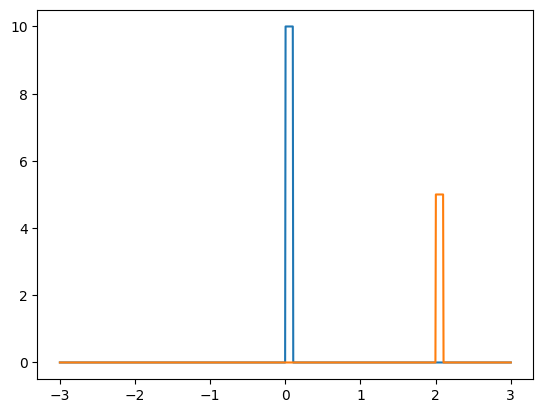

In [ ]:
c = 0.1
def impulse(t):
  return np.logical_and(t >= 0, t <= c) * 1 / c

d = ContinuousSignal(impulse)

d.plot(-3,3,1000)

d2 = d.shift(2).multiply_const_factor(0.5)
d2.plot(-3,3,1000)

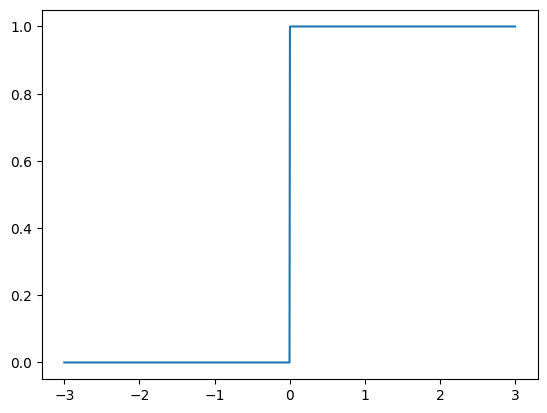

In [ ]:
def impulse_response(t):
  return (t > 0) * 1.0

u = ContinuousSignal(impulse_response)
u.plot()

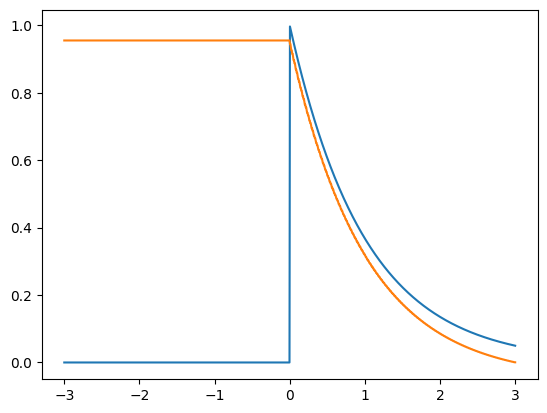

In [ ]:
c = 0.01
def impulse(t):
  return np.logical_and(t >= 0, t < (c - 1e-5)) * 1 / c

def impulse_response(t):
  return (t <= 0) * 1.0

def tgt(t):
  return np.exp(-t) * (t >= 0)

target = ContinuousSignal(tgt)
target.plot(-3, 3, 1000)


delta = ContinuousSignal(impulse_response)

s = None
for i in range(int(3/c)+1):
  t = delta.shift(i * c).multiply_const_factor(c * tgt(i * c))
  s = s.add(t) if s else t
s.plot()
